# Project 02 — Black-Scholes, Greeks & Derivatives Risk

## Notebook 05 — Options Portfolio Risk & Stress Testing

This notebook extends the single-option analysis developed in the previous
notebooks to a multi-position options portfolio.

The analysis constructs an options portfolio containing long and short SPY
option positions, calculates the portfolio's aggregate Greeks, and evaluates
the portfolio under a range of market stress scenarios.

The stress-testing framework compares two approaches:

1. Full Black-Scholes revaluation of every option under each scenario.
2. Delta-Gamma approximation of portfolio P&L using the portfolio Greeks.

The difference between these approaches demonstrates the impact of nonlinear
option risk and illustrates where Greek-based approximations become less
accurate.

### Objectives

- Construct a multi-position SPY options portfolio.
- Represent both long and short option positions.
- Calculate position values and portfolio exposure.
- Calculate aggregate Delta, Gamma, Vega, Theta, and Rho.
- Analyze portfolio P&L under underlying-price shocks.
- Analyze portfolio P&L under volatility shocks.
- Incorporate time decay into stress scenarios.
- Perform combined price and volatility stress testing.
- Fully revalue every option under each stress scenario.
- Estimate portfolio P&L using a Delta-Gamma approximation.
- Compare the approximation with full Black-Scholes revaluation.
- Quantify approximation error.
- Identify the portfolio's primary risk drivers.
- Examine nonlinear effects caused by Gamma.
- Examine volatility sensitivity caused by Vega.
- Discuss the limitations of the stress-testing framework.

The analysis builds on the Black-Scholes pricing framework developed in
Notebook 02, the Greeks analysis developed in Notebook 03, and the implied
volatility analysis developed in Notebook 04.

## 1. Load Market Data

Notebook 01 created the cleaned SPY option-chain dataset, which is reused
throughout Project 02.

The portfolio constructed in this notebook will use contracts from this
dataset so that portfolio valuation, Greeks, and stress testing are based on
the same market snapshot used in the previous analyses.

The option mid-price will be treated as the current market value of each
contract:

$$
P_{mid} = \frac{Bid + Ask}{2}
$$

The Black-Scholes model will then be used to revalue each position under
stressed market conditions.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from project_02_derivatives_risk_engine.src.black_scholes import black_scholes_price
from project_02_derivatives_risk_engine.src.implied_volatility import calculate_implied_volatility
from project_02_derivatives_risk_engine.src.greeks import calculate_greeks
from project_02_derivatives_risk_engine.src.portfolio_risk import revalue_portfolio

In [2]:
data_path = "../results/csv/spy_option_chain_clean.csv"

options = pd.read_csv(data_path)

print(f"Loaded {len(options)} option contracts")

options.head()

Loaded 256 option contracts


,contract_symbol,option_type,expiration,spot,strike,days_to_expiry,T,moneyness,bid,ask,mid_price,last_price,volume,open_interest,implied_volatility,intrinsic_value,time_value,in_the_money
0,SPY261120C00620000,call,2026-11-20,774.886292,620.0,44,0.120548,0.800117,156.37,160.18,158.275,158.81,6.0,45,0.485814,154.886292,3.388708,True
1,SPY261120C00625000,call,2026-11-20,774.886292,625.0,44,0.120548,0.806570,151.51,155.25,153.380,154.00,2.0,7,0.474035,149.886292,3.493708,True
2,SPY261120C00630000,call,2026-11-20,774.886292,630.0,44,0.120548,0.813023,147.20,150.37,148.785,145.85,2.0,785,0.463384,144.886292,3.898708,True
3,SPY261120C00635000,call,2026-11-20,774.886292,635.0,44,0.120548,0.819475,142.34,144.60,143.470,134.00,2.0,141,0.431982,139.886292,3.583708,True
4,SPY261120C00640000,call,2026-11-20,774.886292,640.0,44,0.120548,0.825928,137.35,139.56,138.455,138.85,1.0,414,0.418005,134.886292,3.568708,True


In [3]:
risk_free_rate = 0.04
dividend_yield = 0.015

## 2. Portfolio Construction

An options portfolio consists of multiple option positions with different
strikes, option types, and position directions.

For this notebook, all positions will use the same SPY expiration date,
November 20, 2026. Using a single expiration isolates the portfolio's
strike-dependent and nonlinear risk while avoiding additional effects from
different maturities.

Each portfolio position will identify:

* Option contract
* Option type
* Strike price
* Expiration
* Position direction
* Number of contracts
* Current option price
* Position market value

A positive quantity represents a long position, while a negative quantity
represents a short position.

The portfolio will contain both call and put positions across multiple
strikes. This creates a combination of directional, volatility, and nonlinear
exposures that can be evaluated using portfolio Greeks and stress testing.

For an option position, the market value is:

$$
V_i = Q_i \times P_i \times M
$$

where:

* $Q_i$ = number of contracts
* $P_i$ = option price
* $M$ = contract multiplier

For standard U.S. equity options:

$$
M = 100
$$

The total portfolio value is therefore:

$$
V_{\text{portfolio}} = \sum_i V_i
$$

The same portfolio definition will be used throughout the remainder of the
notebook for Greek aggregation, scenario analysis, full Black-Scholes
revaluation, and Delta-Gamma approximation.

### 2.1 Portfolio Definition

Before constructing the portfolio, the available option strikes are examined
around the current SPY price.

The portfolio will be constructed using contracts from the November 20, 2026
expiration and will include positions across multiple strikes.

The objective is to create a representative options portfolio containing:

- Long call exposure
- Short call exposure
- Long put exposure
- Short put exposure

The selected positions should provide a mixture of directional and nonlinear
risk so that the subsequent Greek aggregation and stress-testing analysis is
meaningful.

The current SPY spot price is approximately $775, so strikes around this
level will be considered when selecting the portfolio positions.

In [4]:
# Inspect available strikes around the current SPY price

spot_price = options["spot"].iloc[0]

strike_summary = (
    options[
        (options["strike"] >= spot_price - 100) &
        (options["strike"] <= spot_price + 100)
    ]
    .loc[:, ["option_type", "strike", "mid_price", "implied_volatility"]]
)

print(f"Current SPY spot price: ${spot_price:.2f}")
strike_summary

Current SPY spot price: $774.89


,option_type,strike,mid_price,implied_volatility
11,call,675.0,104.275,0.358008
12,call,680.0,99.240,0.328437
13,call,685.0,94.905,0.337287
14,call,690.0,89.650,0.310920
15,call,695.0,85.425,0.320472
...,...,...,...,...
248,put,825.0,50.595,0.151498
249,put,830.0,55.050,0.150643
250,put,835.0,59.975,0.156625
251,put,840.0,65.015,0.169656


### 2.2 Portfolio Positions

The portfolio is constructed from the available November 20, 2026 SPY option
contracts identified in the previous step.

Both long and short positions are included so that the portfolio contains
different sources of risk exposure.

The portfolio positions are represented by signed contract quantities:

- Positive quantity → long position
- Negative quantity → short position

Each position will retain the contract's market price, strike, option type,
time to expiration, and implied volatility from the market dataset.

The portfolio will use equal absolute contract quantities across the selected
positions. This keeps the analysis focused on the effects of option structure
rather than introducing additional complexity from position sizing.

The selected portfolio consists of six positions:

| Position | Option Type | Strike | Quantity |
|----------|-------------|-------:|---------:|
| 1 | Long Call | 750 | +10 |
| 2 | Short Call | 800 | -10 |
| 3 | Long Put | 750 | +10 |
| 4 | Short Put | 800 | -10 |
| 5 | Long Call | 775 | +10 |
| 6 | Long Put | 775 | +10 |

This structure provides exposure to both calls and puts, as well as both long
and short positions. The combination of strikes around the current SPY price
also creates meaningful directional and nonlinear risk.

The portfolio will subsequently be used to calculate aggregate Greeks and
evaluate the effect of underlying-price, volatility, and time-decay scenarios.

### 2.3 Position Values and Exposure

Each option position has a market value based on the option's current mid-price
and the number of contracts held.

For a standard U.S. equity option, one contract represents 100 shares of the
underlying.

The market value of position $i$ is therefore:

$$
V_i = Q_i \times P_i \times 100
$$

where:

* $Q_i$ = signed number of contracts
* $P_i$ = current option mid-price
* $100$ = standard option contract multiplier

The sign of the position quantity determines whether the position contributes
positively or negatively to the portfolio value.

The total portfolio market value is:

$$
V_{\text{portfolio}} = \sum_{i=1}^{n} V_i
$$

In addition to market value, the portfolio exposure will be evaluated through
its aggregate Greeks. This allows the analysis to distinguish between the
current value of the portfolio and its sensitivity to changes in market
variables.

In [5]:
# Define the portfolio positions

portfolio_positions = pd.DataFrame({
    "option_type": ["call", "call", "put", "put", "call", "put"],
    "strike": [750, 800, 750, 800, 775, 775],
    "quantity": [10, -10, 10, -10, 10, 10]
})

portfolio_positions

,option_type,strike,quantity
0,call,750,10
1,call,800,-10
2,put,750,10
3,put,800,-10
4,call,775,10
5,put,775,10


In [6]:
# Add market data for each portfolio position

portfolio = portfolio_positions.merge(
    options[
        [
            "option_type",
            "strike",
            "expiration",
            "spot",
            "T",
            "mid_price"
        ]
    ],
    on=["option_type", "strike"],
    how="left"
)

portfolio

,option_type,strike,quantity,expiration,spot,T,mid_price
0,call,750,10,2026-11-20,774.886292,0.120548,35.095
1,call,800,-10,2026-11-20,774.886292,0.120548,5.110
2,put,750,10,2026-11-20,774.886292,0.120548,6.260
3,put,800,-10,2026-11-20,774.886292,0.120548,27.000
4,call,775,10,2026-11-20,774.886292,0.120548,16.580
5,put,775,10,2026-11-20,774.886292,0.120548,12.865


In [7]:
# Calculate position market values

contract_multiplier = 100

portfolio["position_value"] = (
    portfolio["quantity"]
    * portfolio["mid_price"]
    * contract_multiplier
)

portfolio

,option_type,strike,quantity,expiration,spot,T,mid_price,position_value
0,call,750,10,2026-11-20,774.886292,0.120548,35.095,35095.0
1,call,800,-10,2026-11-20,774.886292,0.120548,5.110,-5110.0
2,put,750,10,2026-11-20,774.886292,0.120548,6.260,6260.0
3,put,800,-10,2026-11-20,774.886292,0.120548,27.000,-27000.0
4,call,775,10,2026-11-20,774.886292,0.120548,16.580,16580.0
5,put,775,10,2026-11-20,774.886292,0.120548,12.865,12865.0


### 2.4 Current Portfolio Value

The current portfolio market value is calculated by summing the market values
of all individual option positions.

Because short positions have negative quantities, their values reduce the
portfolio's net market value.

For the constructed portfolio:

$$
V_{\text{portfolio}} = \sum_{i=1}^{n} Q_i P_i M
$$

where $Q_i$ is the signed number of contracts, $P_i$ is the current option
mid-price, and $M$ is the contract multiplier.

The resulting portfolio market value represents the current valuation of the
portfolio before any stress scenario is applied.

This value will serve as the baseline against which all subsequent stressed
portfolio valuations and P&L calculations will be compared.

In [8]:
# Calculate total portfolio market value

portfolio_value = portfolio["position_value"].sum()

print(f"Portfolio market value: ${portfolio_value:,.2f}")

Portfolio market value: $38,690.00


## 3. Portfolio Greeks

The individual option Greeks calculated in the previous notebooks can be
combined across all positions to measure the sensitivity of the entire
portfolio.

For each option position, the relevant Greeks are:

* **Delta** — sensitivity to changes in the underlying price
* **Gamma** — sensitivity of Delta to changes in the underlying price
* **Vega** — sensitivity to changes in implied volatility
* **Theta** — sensitivity to the passage of time
* **Rho** — sensitivity to changes in the risk-free interest rate

The portfolio-level Greek is obtained by summing the corresponding
position-level Greeks, after accounting for the number of contracts and the
standard option contract multiplier.

For example, portfolio Delta is:

$$
\Delta_{\text{portfolio}} = \sum_{i=1}^{n} Q_i \Delta_i M
$$

where:

* $Q_i$ = signed number of contracts
* $\Delta_i$ = Delta of option $i$
* $M$ = contract multiplier

The same aggregation principle is applied to Gamma, Vega, Theta, and Rho.

The resulting portfolio Greeks provide a compact representation of the
portfolio's primary market sensitivities and will later be used to construct
the Delta-Gamma stress approximation.

### 3.1 Position-Level Greeks

The Black-Scholes Greeks calculated in the previous step describe the
sensitivity of each individual option contract.

For portfolio risk analysis, these sensitivities must be adjusted for the
direction and size of each position.

The position-level Greek exposure is calculated as:

$$
G_i^{\text{position}} = Q_i \times G_i \times M
$$

where:

- $Q_i$ = signed number of contracts
- $G_i$ = Greek for option $i$
- $M$ = contract multiplier

The signed quantity ensures that long and short positions contribute
appropriately to the portfolio's overall risk.

The same approach is applied to **Delta, Gamma, Vega, Theta, and Rho**.

In [9]:
# Calculate position-level Greeks

greeks = portfolio.apply(
    lambda row: calculate_greeks(
        S=row["spot"],
        K=row["strike"],
        T=row["T"],
        r=risk_free_rate,
        q=dividend_yield,
        sigma=calculate_implied_volatility(
            market_price=row["mid_price"],
            S=row["spot"],
            K=row["strike"],
            T=row["T"],
            r=risk_free_rate,
            q=dividend_yield,
            option_type=row["option_type"]
        ),
        option_type=row["option_type"]
    ),
    axis=1
)

greeks_df = pd.DataFrame(greeks.tolist(), index=portfolio.index)

portfolio = pd.concat([portfolio, greeks_df], axis=1)

portfolio

,option_type,strike,quantity,expiration,spot,T,mid_price,position_value,delta,gamma,vega,theta,rho
0,call,750,10,2026-11-20,774.886292,0.120548,35.095,35095.0,0.729571,0.006977,88.649286,-77.274686,63.919324
1,call,800,-10,2026-11-20,774.886292,0.120548,5.110,-5110.0,0.258440,0.009648,86.920520,-49.675466,23.525104
2,put,750,10,2026-11-20,774.886292,0.120548,6.260,6260.0,-0.752775,0.007516,84.583708,-49.537854,-23.679420
3,put,800,-10,2026-11-20,774.886292,0.120548,27.000,-27000.0,-0.241255,0.010034,83.806113,-24.366495,-73.961105
4,call,775,10,2026-11-20,774.886292,0.120548,16.580,16580.0,0.531814,0.010215,106.775991,-73.593338,47.678548
5,put,775,10,2026-11-20,774.886292,0.120548,12.865,12865.0,-0.533292,0.011313,106.742533,-48.190273,-44.977703


### 3.2 Portfolio Greek Exposures

The individual position-level Greek exposures are aggregated across all
portfolio positions to obtain the portfolio's total sensitivity.

For each Greek:

$$
G_{\text{portfolio}} = \sum_{i=1}^{n} Q_i G_i M
$$

This produces a single exposure measure for each of the five primary
Black-Scholes Greeks:

* **Delta** — first-order sensitivity to changes in the underlying price
* **Gamma** — sensitivity of Delta to changes in the underlying price
* **Vega** — sensitivity to changes in implied volatility
* **Theta** — sensitivity to the passage of time
* **Rho** — sensitivity to changes in the risk-free interest rate

Using the same aggregation framework for all five Greeks allows the
portfolio's risk profile to be evaluated consistently.

In [10]:
# Standard contract multiplier
contract_multiplier = 100

portfolio["delta_exposure"] = portfolio["quantity"] * portfolio["delta"] * contract_multiplier

portfolio["gamma_exposure"] = portfolio["quantity"] * portfolio["gamma"] * contract_multiplier


portfolio["vega_exposure"] = portfolio["quantity"] * portfolio["vega"] * contract_multiplier

portfolio["theta_exposure"] = portfolio["quantity"] * portfolio["theta"] * contract_multiplier

portfolio["rho_exposure"] = portfolio["quantity"] * portfolio["rho"] * contract_multiplier

portfolio

,option_type,strike,quantity,expiration,spot,T,mid_price,position_value,delta,gamma,vega,theta,rho,delta_exposure,gamma_exposure,vega_exposure,theta_exposure,rho_exposure
0,call,750,10,2026-11-20,774.886292,0.120548,35.095,35095.0,0.729571,0.006977,88.649286,-77.274686,63.919324,729.571363,6.976884,88649.286031,-77274.685819,63919.324150
1,call,800,-10,2026-11-20,774.886292,0.120548,5.110,-5110.0,0.258440,0.009648,86.920520,-49.675466,23.525104,-258.439768,-9.647855,-86920.520272,49675.465618,-23525.104291
2,put,750,10,2026-11-20,774.886292,0.120548,6.260,6260.0,-0.752775,0.007516,84.583708,-49.537854,-23.679420,-752.774758,7.516445,84583.708131,-49537.853683,-23679.420034
3,put,800,-10,2026-11-20,774.886292,0.120548,27.000,-27000.0,-0.241255,0.010034,83.806113,-24.366495,-73.961105,241.255279,-10.033973,-83806.112956,24366.494995,73961.105051
4,call,775,10,2026-11-20,774.886292,0.120548,16.580,16580.0,0.531814,0.010215,106.775991,-73.593338,47.678548,531.813808,10.215341,106775.991069,-73593.338277,47678.548180
5,put,775,10,2026-11-20,774.886292,0.120548,12.865,12865.0,-0.533292,0.011313,106.742533,-48.190273,-44.977703,-533.292313,11.313338,106742.532542,-48190.273102,-44977.702947


In [11]:
# Aggregate portfolio Greeks

greek_names = ["delta", "gamma", "vega", "theta", "rho"]

portfolio_greeks = {
    greek: portfolio[f"{greek}_exposure"].sum()
    for greek in greek_names
}

portfolio_greeks

{'delta': np.float64(-41.86638978794019),
 'gamma': np.float64(16.34017989016916),
 'vega': np.float64(216024.884544198),
 'theta': np.float64(-174554.1902685642),
 'rho': np.float64(93376.75010821482)}

### 3.3 Portfolio Greek Summary and Interpretation

The aggregated portfolio Greeks provide a compact representation of the
portfolio's current risk profile.

#### 1. Delta — Directional Exposure

The portfolio has a Delta of approximately −41.87, indicating relatively
small negative first-order exposure to the SPY underlying.

For a **$1 increase in SPY**, the first-order Delta effect is:

$$
\Delta P\&L \approx \Delta_{\text{portfolio}} \Delta S
$$

With $\Delta S = \$1$:

$$
\Delta P\&L \approx -41.87 \times 1 = -\$41.87
$$

Therefore, ignoring higher-order effects, a $1 increase in SPY would initially
reduce portfolio value by approximately **$41.87**.

---

#### 2. Gamma — Nonlinear Price Exposure

The portfolio has positive Gamma of approximately 16.34. Gamma captures the
change in Delta as SPY moves and therefore introduces a second-order effect.

The Delta-Gamma approximation is:

$$
\Delta P\&L \approx \Delta_{\text{portfolio}} \Delta S + \frac{1}{2} \Gamma_{\text{portfolio}} (\Delta S)^2
$$

For a **$1 increase in SPY**:

$$
\Delta P\&L \approx (-41.87)(1) + \frac{1}{2}(16.34)(1)^2 \approx -\$33.70
$$

The positive Gamma therefore offsets approximately **$8.17** of the
negative Delta effect.

For a **$1 decrease in SPY**:

$$
\Delta P\&L \approx (-41.87)(-1) + \frac{1}{2}(16.34)(-1)^2 \approx +\$50.04
$$

This demonstrates the nonlinear nature of the portfolio: the P&L response
cannot be described by Delta alone.

---

#### 3. Theta — Time Decay

The portfolio Theta is approximately −174,554 per year.

Converting the annualized Theta to a one-day effect:

$$
\Theta_{\text{daily}} = \frac{-174,554}{365} \approx -\$478
$$

Therefore, assuming no changes in SPY, volatility, interest rates, or other market variables, the passage of one day would reduce portfolio value by approximately **$478** due to time decay.

---

#### 4. Vega — Volatility Exposure

Portfolio Vega is approximately 216,025 per unit change in implied volatility.

For a **1 percentage-point increase in implied volatility**:

$$
\Delta P\&L \approx 216,025 \times 0.01 \approx +\$2,160
$$

Therefore, all else equal, a 1 percentage-point increase in implied
volatility would increase portfolio value by approximately **$2,160**.

The positive Vega indicates that the portfolio benefits from an increase in
implied volatility.

---

#### 5. Rho — Interest-Rate Exposure

Portfolio Rho is approximately 93,377 per unit change in the risk-free rate.

For a **1 percentage-point increase in the risk-free rate**:

$$
\Delta P\&L \approx 93,377 \times 0.01 \approx +\$934
$$

Therefore, all else equal, a 1 percentage-point increase in the risk-free
rate would increase portfolio value by approximately **$934**.

---

#### 6. Overall Portfolio Risk Profile

The portfolio is close to Delta-neutral but remains exposed to significant
nonlinear, volatility, and time-decay risks.

The key sensitivities can be summarized as:

| Risk Factor | Scenario | Approx. P&L |
|---|---|---:|
| Delta | SPY +$1, Delta only | **−$41.87** |
| Delta + Gamma | SPY +$1 | **−$33.70** |
| Delta + Gamma | SPY −$1 | **+$50.04** |
| Theta | 1 day | **−$404** |
| Vega | IV +1 percentage point | **+$2,160** |
| Rho | Rate +1 percentage point | **+$934** |

These sensitivities provide the baseline risk profile for the scenario
analysis and full-revaluation stress tests that follow.

## 4. Scenario Analysis

Scenario analysis evaluates how the portfolio responds to changes in key
market variables.

The portfolio Greeks provide local sensitivity measures around the current
market state. Scenario analysis extends this perspective by applying explicit
shocks to the underlying price, implied volatility, and time to expiration.

The scenarios are designed to illustrate both first-order and nonlinear
portfolio behavior.

The analysis will consider:

1. Underlying price scenarios
2. Volatility scenarios
3. Time-decay scenarios
4. Combined price and volatility scenarios

The resulting scenario P&L will provide the basis for the subsequent full
Black-Scholes revaluation and comparison with the Delta-Gamma approximation.

### 4.1 Underlying Price Scenarios

The first scenario analysis examines the effect of changes in the SPY
underlying price.

The current SPY price is approximately $775. A range of upward and downward
price shocks will be applied around this baseline.

The initial scenarios will use:

$$
\Delta S \in \{-10\%, -5\%, -2\%, 0\%, +2\%, +5\%, +10\%\}
$$

These scenarios allow the portfolio's directional and nonlinear exposure to
be examined across a meaningful range of underlying-price movements.

For each scenario, the stressed SPY price is:

$$
S_{\text{scenario}} = S_0(1 + \Delta S)
$$

where:

* $S_0$ = current SPY price
* $\Delta S$ = percentage price shock

The resulting portfolio P&L will initially be estimated using the portfolio's
Delta and Gamma exposures. Full Black-Scholes revaluation will be performed
later to capture the complete nonlinear effect.

In [12]:
# Define SPY price scenarios

spot_price = portfolio["spot"].iloc[0]

price_shocks = np.array([
    -0.10,
    -0.05,
    -0.02,
     0.00,
     0.02,
     0.05,
     0.10
])

scenario_prices = spot_price * (1 + price_shocks)

price_scenarios = pd.DataFrame({
    "price_shock": price_shocks,
    "spot_price": scenario_prices
})

price_scenarios

,price_shock,spot_price
0,-0.10,697.397662
1,-0.05,736.141977
2,-0.02,759.388566
3,0.00,774.886292
4,0.02,790.384017
5,0.05,813.630606
6,0.10,852.374921


### 4.1.1 Delta-Gamma Scenario P&L

The portfolio's response to an underlying-price shock can be approximated
using its aggregate Delta and Gamma.

The Delta-Gamma approximation is:

$$
\Delta P\&L
\approx
\Delta_{portfolio}\Delta S
+
\frac{1}{2}
\Gamma_{portfolio}(\Delta S)^2
$$

where:

- $\Delta S$ = change in SPY price from the current spot price
- $\Delta_{portfolio}$ = portfolio Delta
- $\Gamma_{portfolio}$ = portfolio Gamma

The Delta component captures the first-order directional effect, while the
Gamma component captures the nonlinear effect caused by changes in Delta.

The approximation will be calculated for each underlying-price scenario.

In [13]:
# Calculate Delta-Gamma P&L for each price scenario

portfolio_delta = portfolio_greeks["delta"]
portfolio_gamma = portfolio_greeks["gamma"]

price_scenarios["delta_s"] = price_scenarios["spot_price"] - spot_price

price_scenarios["delta_pnl"] = portfolio_delta * price_scenarios["delta_s"]

price_scenarios["gamma_pnl"] = 0.5 * portfolio_gamma * price_scenarios["delta_s"] ** 2

price_scenarios["delta_gamma_pnl"] = price_scenarios["delta_pnl"] + price_scenarios["gamma_pnl"]

price_scenarios

,price_shock,spot_price,delta_s,delta_pnl,gamma_pnl,delta_gamma_pnl
0,-0.10,697.397662,-77.488629,3244.169152,49057.204155,52301.373307
1,-0.05,736.141977,-38.744315,1622.084576,12264.301039,13886.385615
2,-0.02,759.388566,-15.497726,648.833830,1962.288166,2611.121997
3,0.00,774.886292,0.000000,-0.000000,0.000000,0.000000
4,0.02,790.384017,15.497726,-648.833830,1962.288166,1313.454336
5,0.05,813.630606,38.744315,-1622.084576,12264.301039,10642.216463
6,0.10,852.374921,77.488629,-3244.169152,49057.204155,45813.035003


### 4.2 Volatility Scenarios

The second scenario analysis examines the effect of changes in implied
volatility on the portfolio.

Portfolio Vega measures the sensitivity of portfolio value to changes in
implied volatility. The current portfolio has positive Vega, indicating that
an increase in implied volatility should increase portfolio value, all else
equal.

The volatility scenarios will apply shocks of:

$$
\Delta\sigma \in
\{-5\%, -2\%, 0\%, +2\%, +5\%\}
$$

These represent **absolute changes in implied volatility**, rather than
percentage changes in volatility.

For example, if an option has an implied volatility of 20%, a +2 percentage
point shock produces a stressed volatility of 22%.

The initial volatility P&L estimate will use portfolio Vega:

$$
\Delta P\&L
\approx
Vega_{portfolio}\Delta\sigma
$$

This provides a first-order estimate of the portfolio's sensitivity to
volatility changes. Full option revaluation under stressed volatility will
be performed later.

In [14]:
# Define volatility scenarios

volatility_shocks = np.array([
    -0.05,
    -0.02,
     0.00,
     0.02,
     0.05
])

volatility_scenarios = pd.DataFrame({
    "volatility_shock": volatility_shocks
})

volatility_scenarios["vega_pnl"] = (
    portfolio_greeks["vega"]
    * volatility_scenarios["volatility_shock"]
)

volatility_scenarios

,volatility_shock,vega_pnl
0,-0.05,-10801.244227
1,-0.02,-4320.497691
2,0.00,0.000000
3,0.02,4320.497691
4,0.05,10801.244227


### 4.3 Time-Decay Scenarios

The third scenario analysis examines the effect of the passage of time on the
portfolio.

As an option approaches expiration, its time value generally changes. Portfolio
Theta measures the sensitivity of portfolio value to the passage of time.

The portfolio's current time to expiration is approximately 0.1205 years.
Time-decay scenarios will evaluate the effect of:

* 1 day
* 5 days
* 10 days
* 20 days

of elapsed time.

The stressed time to expiration is calculated as:

$$
T_{\text{scenario}} = T_0 - \frac{d}{365}
$$

where:

* $T_0$ = current time to expiration
* $d$ = number of elapsed days

The initial P&L estimate will use portfolio Theta:

$$
\Delta P\&L \approx \Theta_{\text{portfolio}} \frac{d}{365}
$$

This provides a first-order estimate of the portfolio's time-decay effect.
Full Black-Scholes revaluation using the reduced time to expiration will be
performed later.

In [15]:
# Define time-decay scenarios

days_elapsed = np.array([
    1,
    5,
    10,
    20
])

time_scenarios = pd.DataFrame({
    "days_elapsed": days_elapsed
})

time_scenarios["T_scenario"] = (
    portfolio["T"].iloc[0]
    - time_scenarios["days_elapsed"] / 365
)

time_scenarios["theta_pnl"] = (
    portfolio_greeks["theta"]
    * time_scenarios["days_elapsed"]
    / 365
)

time_scenarios

,days_elapsed,T_scenario,theta_pnl
0,1,0.117808,-478.230658
1,5,0.106849,-2391.153291
2,10,0.093151,-4782.306583
3,20,0.065753,-9564.613165


### 4.4 Combined Price and Volatility Scenarios

The previous scenario analyses isolated the effects of changes in the
underlying price and implied volatility.

In practice, these variables can move simultaneously. A market sell-off, for
example, may be accompanied by an increase in implied volatility.

This section combines SPY price shocks with volatility shocks to examine the
portfolio's sensitivity to simultaneous market movements.

The combined scenarios will use:

- SPY price shocks: -10%, -5%, -2%, 0%, +2%, +5%, +10%
- Implied volatility shocks: -5, -2, 0, +2, +5 percentage points

For each combination, the approximate portfolio P&L is calculated using the
portfolio's Delta, Gamma, and Vega:

$$
\Delta P\&L
\approx
\Delta_{portfolio}\Delta S
+
\frac{1}{2}\Gamma_{portfolio}(\Delta S)^2
+
Vega_{portfolio}\Delta\sigma
$$

where:

- $\Delta S$ = change in SPY price
- $\Delta\sigma$ = change in implied volatility
- $\Delta_{portfolio}$ = portfolio Delta
- $\Gamma_{portfolio}$ = portfolio Gamma
- $Vega_{portfolio}$ = portfolio Vega

This produces a two-dimensional stress matrix showing how simultaneous
underlying-price and volatility movements affect the portfolio.

The combined scenarios provide a more realistic representation of portfolio
risk before full Black-Scholes revaluation is introduced in the next section.

In [16]:
# Define combined price and volatility scenarios

combined_scenarios = []

for price_shock in price_shocks:

    delta_s = spot_price * price_shock

    delta_pnl = (
        portfolio_greeks["delta"]
        * delta_s
    )

    gamma_pnl = (
        0.5
        * portfolio_greeks["gamma"]
        * delta_s ** 2
    )

    for volatility_shock in volatility_shocks:

        vega_pnl = (
            portfolio_greeks["vega"]
            * volatility_shock
        )

        total_pnl = (
            delta_pnl
            + gamma_pnl
            + vega_pnl
        )

        combined_scenarios.append({
            "price_shock": price_shock,
            "volatility_shock": volatility_shock,
            "spot_price": spot_price + delta_s,
            "delta_pnl": delta_pnl,
            "gamma_pnl": gamma_pnl,
            "vega_pnl": vega_pnl,
            "total_pnl": total_pnl
        })

combined_scenarios = pd.DataFrame(combined_scenarios)

combined_scenarios

,price_shock,volatility_shock,spot_price,delta_pnl,gamma_pnl,vega_pnl,total_pnl
0,-0.10,-0.05,697.397662,3244.169152,49057.204155,-10801.244227,41500.129080
1,-0.10,-0.02,697.397662,3244.169152,49057.204155,-4320.497691,47980.875616
2,-0.10,0.00,697.397662,3244.169152,49057.204155,0.000000,52301.373307
3,-0.10,0.02,697.397662,3244.169152,49057.204155,4320.497691,56621.870998
4,-0.10,0.05,697.397662,3244.169152,49057.204155,10801.244227,63102.617534
5,-0.05,-0.05,736.141977,1622.084576,12264.301039,-10801.244227,3085.141388
6,-0.05,-0.02,736.141977,1622.084576,12264.301039,-4320.497691,9565.887924
7,-0.05,0.00,736.141977,1622.084576,12264.301039,0.000000,13886.385615
8,-0.05,0.02,736.141977,1622.084576,12264.301039,4320.497691,18206.883306
9,-0.05,0.05,736.141977,1622.084576,12264.301039,10801.244227,24687.629842


#### 4.4.1 Combined Scenario Stress Matrix

The combined scenarios can be arranged into a stress matrix with SPY price
shocks on one axis and implied-volatility shocks on the other.

Each cell represents the estimated portfolio P&L under the corresponding
combination of underlying-price and volatility shocks.

The matrix provides a compact view of how the portfolio responds when
directional and volatility risks occur simultaneously.

Positive values represent estimated gains, while negative values represent
estimated losses.

In [17]:
# Create combined P&L stress matrix

stress_matrix = combined_scenarios.pivot(
    index="price_shock",
    columns="volatility_shock",
    values="total_pnl"
)

stress_matrix.style.format("${:,.0f}")

volatility_shock,-0.050000,-0.020000,0.000000,0.020000,0.050000
price_shock,,,,,
-0.100000,"$41,500","$47,981","$52,301","$56,622","$63,103"
-0.050000,"$3,085","$9,566","$13,886","$18,207","$24,688"
-0.020000,"$-8,190","$-1,709","$2,611","$6,932","$13,412"
0.000000,"$-10,801","$-4,320",$0,"$4,320","$10,801"
0.020000,"$-9,488","$-3,007","$1,313","$5,634","$12,115"
0.050000,$-159,"$6,322","$10,642","$14,963","$21,443"
0.100000,"$35,012","$41,493","$45,813","$50,134","$56,614"


## 5. Full Revaluation Stress Testing

The previous section estimated portfolio P&L using Delta, Gamma, and Vega
sensitivities.

This section performs a full Black-Scholes revaluation of every option
position under the same stress scenarios.

For each price and volatility stress scenario, the stressed SPY price and
implied volatility are applied to every portfolio position.

Time-to-expiration effects are analyzed separately through the time-decay
scenarios in Section 4.3.

Each option is then repriced using the Black-Scholes model.

The stressed portfolio value is calculated as:

$$
V_{\text{portfolio}}^{\text{stress}} = \sum_{i=1}^{n} Q_i P_i^{\text{stress}} M
$$

where:

* $Q_i$ = signed position quantity
* $P_i^{\text{stress}}$ = Black-Scholes price under the stressed scenario
* $M$ = contract multiplier

The portfolio P&L is then:

$$
P\&L_{\text{stress}} = V_{\text{portfolio}}^{\text{stress}} - V_{\text{portfolio}}^{\text{current}}
$$

Unlike the Delta-Gamma approximation, full revaluation captures the complete
nonlinear behavior of the Black-Scholes pricing function.

The full-revaluation results will subsequently be compared with the
Delta-Gamma-Vega approximation to quantify the error introduced by the
Greek-based approach.

### 5.1 Black-Scholes Revaluation

For each stress scenario, every option in the portfolio is repriced using the
Black-Scholes model.

The stressed option price is calculated using:

- Stressed SPY price
- Original strike
- Stressed time to expiration
- Stressed implied volatility
- Current risk-free rate
- Current dividend yield

The option's strike, type, and position quantity remain unchanged.

This approach allows the entire portfolio to be revalued consistently under
each scenario rather than approximating the effect through local sensitivities.

### 5.2 Portfolio P&L

The stressed portfolio value is converted into portfolio P&L by comparing it
with the current portfolio market value.

$$
P\&L_{\text{stress}} = V_{\text{portfolio}}^{\text{stress}} - V_{\text{portfolio}}^{\text{current}}
$$

A positive value represents a gain relative to the current portfolio value,
while a negative value represents a loss.

The current portfolio value is based on the observed option mid-prices,
whereas stressed values are obtained through Black-Scholes revaluation.

In [18]:
stress_value = revalue_portfolio(
    portfolio=portfolio,
    spot=spot_price,
    risk_free_rate=risk_free_rate,
    dividend_yield=dividend_yield
)

stress_pnl = stress_value - portfolio_value

print(f"Current Portfolio Value : ${portfolio_value:,.2f}")
print(f"Revalued Portfolio Value: ${stress_value:,.2f}")
print(f"Portfolio P&L            : ${stress_pnl:,.2f}")

Current Portfolio Value : $38,690.00
Revalued Portfolio Value: $38,690.00
Portfolio P&L            : $0.00


### 5.3 Stress-Test Matrix

The portfolio is fully revalued under each combination of underlying-price and
volatility shocks.

For each scenario:

1. The underlying price is shifted according to the specified price shock.
2. Implied volatility is adjusted by the specified volatility shock.
3. Each option is repriced using Black-Scholes.
4. Position quantities and the contract multiplier are applied.
5. The individual position values are aggregated into a stressed portfolio
   value.
6. Portfolio P&L is calculated relative to the current portfolio value.

The resulting matrix shows the portfolio's nonlinear response to simultaneous
changes in the underlying price and implied volatility.

In [19]:
full_revaluation_scenarios = []

for price_shock in price_shocks:

    scenario_spot = spot_price * (1 + price_shock)

    for volatility_shock in volatility_shocks:

        stressed_value = revalue_portfolio(
            portfolio=portfolio,
            spot=scenario_spot,
            risk_free_rate=risk_free_rate,
            dividend_yield=dividend_yield,
            volatility_shock=volatility_shock
        )

        stressed_pnl = stressed_value - portfolio_value

        full_revaluation_scenarios.append({
            "price_shock": price_shock,
            "volatility_shock": volatility_shock,
            "spot_price": scenario_spot,
            "portfolio_value": stressed_value,
            "pnl": stressed_pnl
        })

full_revaluation_scenarios = pd.DataFrame(
    full_revaluation_scenarios
)

full_revaluation_matrix = full_revaluation_scenarios.pivot(
    index="price_shock",
    columns="volatility_shock",
    values="pnl"
)

full_revaluation_matrix.style.format("{:,.0f}")

volatility_shock,-0.050000,-0.020000,0.000000,0.020000,0.050000
price_shock,,,,,
-0.100000,"-12,288","-10,348","-8,349","-5,787","-1,058"
-0.050000,"-36,976","-28,936","-23,201","-17,454","-9,050"
-0.020000,"-29,833","-19,939","-13,898","-8,243",-302
0.000000,"-11,396","-4,388",0,"4,275","10,574"
0.020000,"13,814","15,780","17,789","20,198","24,359"
0.050000,"48,769","46,904","46,491","46,720","48,085"
0.100000,"90,615","90,339","89,971","89,595","89,302"


### 5.4 Worst-Case Scenarios

The full-revaluation stress matrix can be used to identify the scenarios
producing the largest portfolio losses and gains.

The worst-case scenario is defined as the scenario with the minimum portfolio
P&L, while the best-case scenario is the scenario with the maximum portfolio
P&L.

In [20]:
worst_case = full_revaluation_scenarios.loc[
    full_revaluation_scenarios["pnl"].idxmin()
]

best_case = full_revaluation_scenarios.loc[
    full_revaluation_scenarios["pnl"].idxmax()
]

print("Worst-Case Scenario")
print(worst_case)

print("\nBest-Case Scenario")
print(best_case)

Worst-Case Scenario
price_shock            -0.050000
volatility_shock       -0.050000
spot_price            736.141977
portfolio_value      1713.961673
pnl                -36976.038327
Name: 5, dtype: float64

Best-Case Scenario
price_shock              0.100000
volatility_shock        -0.050000
spot_price             852.374921
portfolio_value     129304.767900
pnl                  90614.767900
Name: 30, dtype: float64


In [21]:
worst_pnl = worst_case["pnl"]
best_pnl = best_case["pnl"]

print(f"Worst-Case P&L: ${worst_pnl:,.2f}")
print(f"Best-Case P&L : ${best_pnl:,.2f}")

Worst-Case P&L: $-36,976.04
Best-Case P&L : $90,614.77


## 6. Delta-Gamma Approximation

The Delta-Gamma approximation estimates the change in portfolio value using
the portfolio's first- and second-order sensitivity to the underlying price.

The approximation is given by:

$$
\Delta P\&L
\approx
\Delta_{portfolio}\Delta S
+
\frac{1}{2}
\Gamma_{portfolio}(\Delta S)^2
$$

where:

- $\Delta_{portfolio}$ is the portfolio Delta.
- $\Gamma_{portfolio}$ is the portfolio Gamma.
- $\Delta S$ is the change in the underlying price.

This approximation captures both the linear effect of Delta and the
second-order nonlinear effect of Gamma.

It does not fully capture changes in implied volatility, time decay, or
higher-order Greeks.

### 6.1 Taylor Expansion

The Delta-Gamma approximation is derived from a second-order Taylor expansion
of the portfolio value around the current underlying price.

$$
V(S+\Delta S)
\approx
V(S)
+
\Delta \Delta S
+
\frac{1}{2}\Gamma(\Delta S)^2
$$

Therefore:

$$
\Delta V
\approx
\Delta \Delta S
+
\frac{1}{2}\Gamma(\Delta S)^2
$$

The approximation becomes increasingly less accurate as the underlying moves
farther from the current valuation point.

### 6.2 Approximate Portfolio P&L

In [22]:
delta_gamma_scenarios = price_scenarios[
    [
        "price_shock",
        "spot_price",
        "delta_gamma_pnl"
    ]
].copy()

delta_gamma_scenarios.style.format({
    "price_shock": "{:.0%}",
    "spot_price": "${:,.2f}",
    "delta_gamma_pnl": "${:,.0f}"
})

,price_shock,spot_price,delta_gamma_pnl
0,-10%,$697.40,"$52,301"
1,-5%,$736.14,"$13,886"
2,-2%,$759.39,"$2,611"
3,0%,$774.89,$0
4,2%,$790.38,"$1,313"
5,5%,$813.63,"$10,642"
6,10%,$852.37,"$45,813"


### 6.3 Compare with Full Revaluation

The Delta-Gamma approximation is compared with full Black-Scholes
revaluation under pure underlying-price shocks.

To isolate the effect of the underlying price, the comparison uses scenarios
with no volatility shock.

This allows the difference between the two methods to primarily reflect the
limitations of the second-order Delta-Gamma approximation.

In [23]:
full_revaluation_price_only = (
    full_revaluation_scenarios[
        full_revaluation_scenarios["volatility_shock"] == 0
    ][
        ["price_shock", "spot_price", "pnl"]
    ]
    .rename(columns={"pnl": "full_revaluation_pnl"})
)

comparison = delta_gamma_scenarios.merge(
    full_revaluation_price_only,
    on=["price_shock", "spot_price"],
    how="left"
)

comparison

,price_shock,spot_price,delta_gamma_pnl,full_revaluation_pnl
0,-0.10,697.397662,52301.373307,-8.348991e+03
1,-0.05,736.141977,13886.385615,-2.320134e+04
2,-0.02,759.388566,2611.121997,-1.389827e+04
3,0.00,774.886292,0.000000,9.036739e-09
4,0.02,790.384017,1313.454336,1.778919e+04
5,0.05,813.630606,10642.216463,4.649121e+04
6,0.10,852.374921,45813.035003,8.997117e+04


### 6.4 Approximation Error

The difference between the Delta-Gamma approximation and full Black-Scholes
revaluation is quantified using absolute error, mean absolute error, and
root mean squared error.

In [24]:
comparison["difference"] = (
    comparison["full_revaluation_pnl"]
    - comparison["delta_gamma_pnl"]
)

comparison["absolute_error"] = (
    comparison["difference"].abs()
)

comparison.style.format({
    "price_shock": "{:.0%}",
    "spot_price": "${:,.2f}",
    "delta_gamma_pnl": "${:,.0f}",
    "full_revaluation_pnl": "${:,.0f}",
    "difference": "${:,.0f}",
    "absolute_error": "${:,.0f}"
})

,price_shock,spot_price,delta_gamma_pnl,full_revaluation_pnl,difference,absolute_error
0,-10%,$697.40,"$52,301","$-8,349","$-60,650","$60,650"
1,-5%,$736.14,"$13,886","$-23,201","$-37,088","$37,088"
2,-2%,$759.39,"$2,611","$-13,898","$-16,509","$16,509"
3,0%,$774.89,$0,$0,$0,$0
4,2%,$790.38,"$1,313","$17,789","$16,476","$16,476"
5,5%,$813.63,"$10,642","$46,491","$35,849","$35,849"
6,10%,$852.37,"$45,813","$89,971","$44,158","$44,158"


In [25]:
rmse = np.sqrt(
    np.mean(comparison["difference"] ** 2)
)

mae = comparison["absolute_error"].mean()

print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"RMSE               : ${rmse:,.2f}")

Mean Absolute Error: $30,104.34
RMSE               : $35,522.76


## 7. Stress-Test Results

The stress-testing results provide a consolidated view of the portfolio's
behavior under changes in the underlying price and implied volatility.

The analysis focuses on:

- Portfolio P&L across underlying-price scenarios.
- The effect of Gamma on the P&L profile.
- The effect of Vega on volatility sensitivity.
- The difference between local Greek approximations and full revaluation.
- The resulting nonlinear risk profile.

### 7.1 P&L Profile

The P&L profile shows how portfolio value changes as the SPY price moves
away from the current valuation level.

The full Black-Scholes revaluation is compared with the Delta-Gamma
approximation under zero volatility shock.

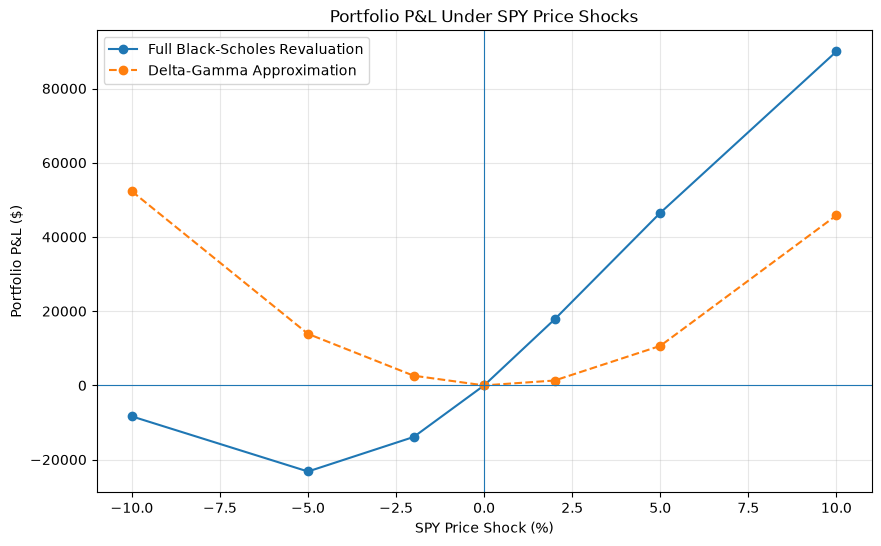

In [26]:
plt.figure(figsize=(10, 6))

plt.plot(
    comparison["price_shock"] * 100,
    comparison["full_revaluation_pnl"],
    marker="o",
    label="Full Black-Scholes Revaluation"
)

plt.plot(
    comparison["price_shock"] * 100,
    comparison["delta_gamma_pnl"],
    marker="o",
    linestyle="--",
    label="Delta-Gamma Approximation"
)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("SPY Price Shock (%)")
plt.ylabel("Portfolio P&L ($)")
plt.title("Portfolio P&L Under SPY Price Shocks")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### 7.2 Gamma Effects

Gamma measures the rate of change of portfolio Delta with respect to changes
in the underlying price.

A positive portfolio Gamma produces convexity in the portfolio's P&L profile:
the portfolio tends to benefit from sufficiently large moves in either
direction, all else equal.

However, the actual portfolio P&L also depends on the individual option
positions, their strikes, and their changing moneyness. Therefore, Gamma
provides a local measure of convexity rather than a complete description of
the portfolio's stress behavior.

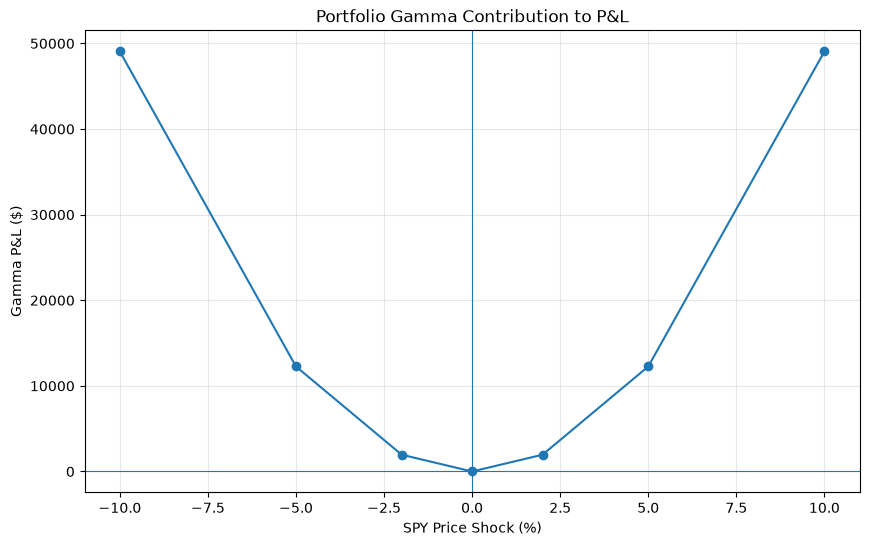

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(
    price_scenarios["price_shock"] * 100,
    price_scenarios["gamma_pnl"],
    marker="o"
)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("SPY Price Shock (%)")
plt.ylabel("Gamma P&L ($)")
plt.title("Portfolio Gamma Contribution to P&L")

plt.grid(True, alpha=0.3)

plt.show()

### 7.3 Vega Effects

Vega measures the sensitivity of the portfolio value to changes in implied
volatility.

The first-order Vega contribution is:

$$
P\&L_{\text{Vega}} = \text{Vega}_{\text{portfolio}} \Delta\sigma
$$

The portfolio has positive Vega, so an increase in implied volatility
produces a positive first-order P&L, while a decrease in implied volatility
produces a negative first-order P&L.

The volatility sensitivity can be examined independently from the underlying
price effects using the volatility scenarios defined earlier.

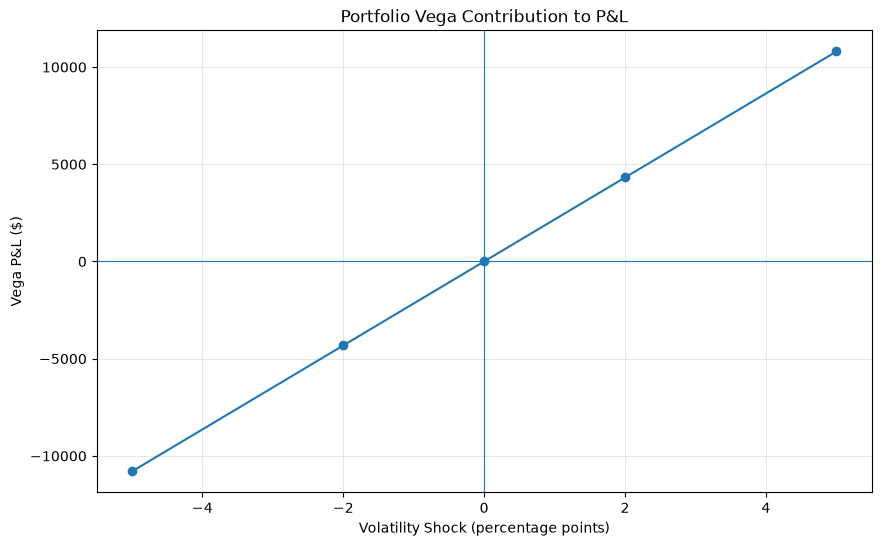

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(
    volatility_scenarios["volatility_shock"] * 100,
    volatility_scenarios["vega_pnl"],
    marker="o"
)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("Volatility Shock (percentage points)")
plt.ylabel("Vega P&L ($)")
plt.title("Portfolio Vega Contribution to P&L")

plt.grid(True, alpha=0.3)

plt.show()

### 7.4 Nonlinear Risk

The stress-testing results demonstrate that the portfolio's risk cannot be
fully described by its current Delta.

The portfolio has relatively low net Delta but meaningful positive Gamma.
Consequently, the portfolio's sensitivity changes as SPY moves away from the
current valuation level.

The comparison between Delta-Gamma approximation and full Black-Scholes
revaluation demonstrates this effect clearly.

Delta-Gamma provides a local approximation around the current valuation point, but the divergence becomes material as the underlying moves away from spot; for this portfolio, substantial differences are already visible at ±2% price shocks.

The short 800 put is particularly important under downward price shocks.
When SPY falls substantially below the strike, the position becomes deeply
in-the-money and generates a large loss for the short position.

Therefore, the portfolio exhibits significant nonlinear downside risk despite
having relatively small net Delta at the current valuation point.

Full revaluation is consequently more appropriate for large stress scenarios,
while Delta-Gamma provides a computationally efficient local approximation
for relatively small movements.

## 8. Risk Interpretation

The portfolio is approximately Delta-neutral at the current valuation point,
but its risk profile is strongly influenced by Gamma, Vega, and Theta.

1. **Delta Risk**

   The portfolio has a small negative net Delta, indicating limited
   first-order exposure to small movements in SPY.

2. **Gamma Risk**

   Positive Gamma creates nonlinear exposure to the underlying price.
   The portfolio's Delta changes as SPY moves away from the current level,
   making large price shocks materially different from small movements.

3. **Volatility Risk**

   Positive Vega means that increases in implied volatility generally benefit
   the portfolio, while volatility decreases create losses, all else equal.

4. **Time-Decay Risk**

   Negative Theta creates a persistent cost from the passage of time,
   assuming other market variables remain unchanged.

5. **Nonlinear Stress Risk**

   Full Black-Scholes revaluation produces materially different results from
   the Delta-Gamma approximation under larger price shocks. This demonstrates
   that local Greek approximations can become unreliable when options move
   significantly through different moneyness regions.

6. **Modeling Implication**

   Delta-Gamma analysis is useful for fast, local risk estimation, while full
   revaluation is more appropriate for larger stress scenarios where nonlinear
   option behavior becomes significant.

## 9. Key Findings

- The portfolio combines long and short SPY options across multiple strikes,
  producing a relatively small net Delta but significant nonlinear exposure.

- Portfolio Gamma is positive, creating meaningful convexity in the
  underlying-price P&L profile.

- Positive Vega makes the portfolio sensitive to changes in implied
  volatility, while negative Theta creates exposure to time decay.

- Full Black-Scholes revaluation captures nonlinear option behavior that is
  not fully represented by Delta-Gamma approximation.

- The difference between the two approaches becomes particularly significant
  under larger underlying-price shocks.

- The short 800 put is a major contributor to downside stress losses when SPY
  falls substantially below the strike.

- Delta-Gamma approximation is therefore most appropriate for relatively small
  movements around the current valuation point.

- Full revaluation provides a more reliable framework for large stress
  scenarios involving substantial changes in the underlying price.

- The notebook demonstrates the importance of combining Greek-based risk
  measures with full-revaluation stress testing when assessing derivatives
  portfolios.